# Marhia José Granada Restrepo

## Problem Set 0

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


### Problema 8

Use el m ́etodo de Leapfrog para encontrar la soluci ́on num ́erica de las siguientes ecuaciones
diferenciales, partiendo de las condiciones iniciales provistas. En cada caso haga un gr ́afico de
la soluci ́on en un intervalo adecuadamente escogido.


a) d
2y
dt2
= −
y
t
2
, con y(1) = 1 y dy
dt(1) = 0

b) y
′′ − 2y
′ + 3y = 0, con y(0) = 1, y′
(0) = 0

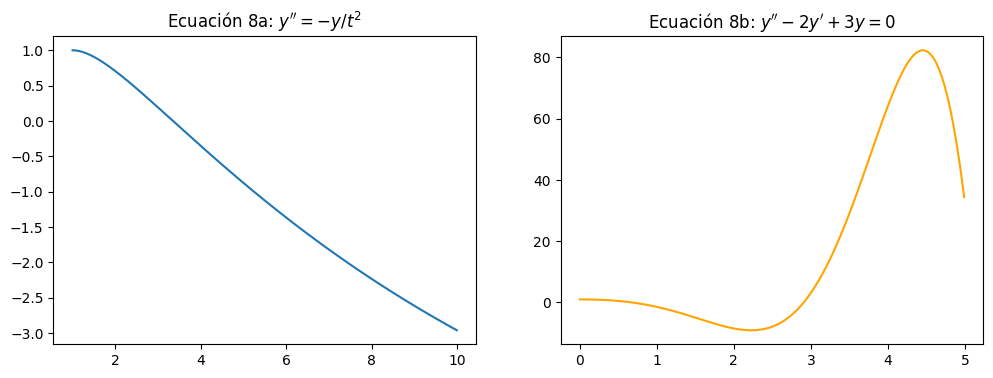

In [2]:
def leapfrog(func, y0, v0, t_span, dt):
    t = np.arange(t_span[0], t_span[1], dt)
    y = np.zeros(len(t))
    v = np.zeros(len(t))
    y[0], v[0] = y0, v0
    
    # Half step for velocity
    v_half = v[0] + 0.5 * dt * func(t[0], y[0], v[0])
    
    for i in range(len(t)-1): 
        y[i+1] = y[i] + dt * v_half
        a_next = func(t[i+1], y[i+1], v_half) 
        v[i+1] = v_half + 0.5 * dt * a_next
        v_half = v_half + dt * a_next
        
    return t, y


# Numeral a) 
accel_a = lambda t, y, v: -y / (t**2)
t_a, y_a = leapfrog(accel_a, 1.0, 0.0, (1, 10), 0.01)

# Numeral b)
accel_b = lambda t, y, v: 2*v - 3*y
t_b, y_b = leapfrog(accel_b, 1.0, 0.0, (0, 5), 0.01)

# Gráficas
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t_a, y_a, label='Solución 8a')
ax[0].set_title("Ecuación 8a: $y'' = -y/t^2$")
ax[1].plot(t_b, y_b, color='orange', label='Solución 8b')
ax[1].set_title("Ecuación 8b: $y'' - 2y' + 3y = 0$")
plt.show()

### Problema 9

La ecuaci ́on diferencial para el `angulo θ, que forma un p ́endulo con la vertical sobre el cual
tambi ́en act ́ua la fricci ́on del aire, es de la forma:


 ̈θ(t) + b
 ̇θ(t) + c sin θ(t) = 0
2

donde b y c son constantes positivas. Escriba un código que solucione esta ecuación diferencial
y proporcione en una misma gr ́afica las soluciones para θ(t) y  ̇θ(t).

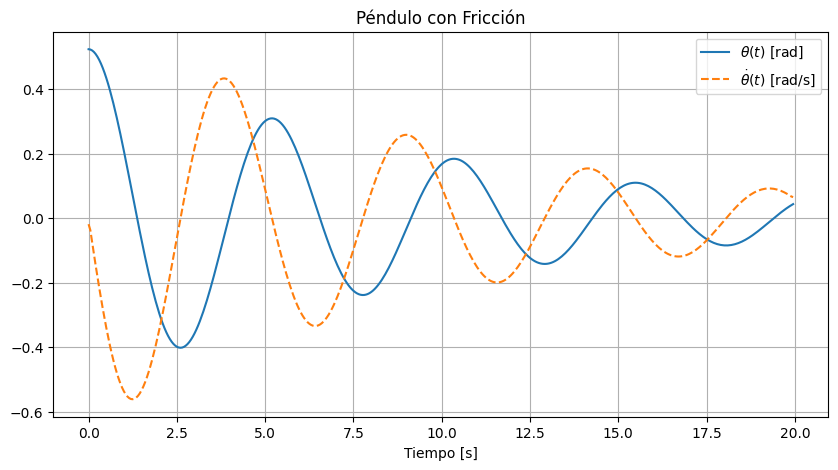

In [4]:
# Parámetros arbitrarios 
b, c = 0.2, 1.5 
theta0, v0 = np.radians(30), 0.0 
dt = 0.05 # paso
t_final = 20

def pendulo_accel(t, theta, v):
    return -b*v - c*np.sin(theta)

t_p, theta_p = leapfrog(pendulo_accel, theta0, v0, (0, t_final), dt)

v_p = np.gradient(theta_p, dt)

plt.figure(figsize=(10, 5))
plt.plot(t_p, theta_p, label=r'$\theta(t)$ [rad]')
plt.plot(t_p, v_p, label=r'$\dot{\theta}(t)$ [rad/s]', linestyle='--')
plt.title("Péndulo con Fricción")
plt.xlabel("Tiempo [s]")
plt.legend()
plt.grid()
plt.show()

### Problema 14

Encuentre los vectores de estado del Sol, J ́upiter y Saturno medidos respecto al baricentro del
sistema solar (origen inercial) para el d ́ıa lunes 6 de abril de 2026 a las 22:00:00 UT y, con
base en esto:

a) Encuentre la inclinaci ́on del plano invariable de Laplace del sistema Sol–J ́upiter–Saturno
con respecto al plano de la ecl ́ıptica.


b) Compare la ubicaci ́on de este plano invariable con la ubicaci ́on de los planos de las  ́orbitas
de J ́upiter y Saturno, sabiendo que la inclinación de sus  ́orbitas (medidas respecto a la
eclíptica) son respectivamente 1°18′ y 2°29′

In [25]:
# Masas en masas solares
m_sol = 1.0
m_jup = 0.000954
m_sat = 0.000285

# Datos de posición (AU) y velocidad (AU/día) al 1 de enero de 2024 con pymcel
Sol, ts, salida = pc.consulta_horizons(id="Sun", epochs='2024-01-01')
Jup, ts, salida = pc.consulta_horizons(id=599, epochs='2024-01-01')
Sat, ts, salida = pc.consulta_horizons(id=699, epochs='2024-01-01')

data = {'Sol': Sol, 'Jup': Jup, 'Sat': Sat}
L_tot = np.zeros(3)

for body, m in zip(['Sol', 'Jup', 'Sat'], [m_sol, m_jup, m_sat]):
    # Extraemos los valores escalares usando .values[0] o convirtiendo a float
    r = np.array([float(data[body]['x']), float(data[body]['y']), float(data[body]['z'])])
    v = np.array([float(data[body]['vx']), float(data[body]['vy']), float(data[body]['vz'])])
    
    # Momento angular: L = m * (r x v)
    L_tot += m * np.cross(r, v)

# Magnitud y ángulo con la eclíptica
L_norm = np.linalg.norm(L_tot)
incl_rad = np.arccos(L_tot[2] / L_norm)
incl_deg = np.degrees(incl_rad)

print(f"Vector L: {L_tot}")
print(f"Inclinación del Plano de Laplace: {incl_deg:.4f} grados")

Vector L: [1.43723252e-06 4.17532612e-07 5.24774769e-05]
Inclinación del Plano de Laplace: 1.6336 grados


In [ ]:
# Comparamos la inclinación del plano de Laplace con las inclinaciones de Júpiter y Saturno
incl_jup = 1 + 18/60  # Convertimos a grados decimales
incl_sat = 2 + 29/60  # Convertimos a grados decimales
print(f"Inclinación de Júpiter: {incl_jup:.4f} grados")
print(f"Inclinación de Saturno: {incl_sat:.4f} grados")
print(f"Inclinación del Plano de Laplace: {incl_deg:.4f} grados")

Inclinación de Júpiter: 1.3000 grados
Inclinación de Saturno: 2.4833 grados
Inclinación del Plano de Laplace: 1.6336 grados


Tenemos entonces que el plano de Laplace está más cerca de la inclinación de Júpiter, lo que es consistente con la idea de que Júpiter domina el momento angular del sistema.